# Análise Exploratória: Ensino da Robótica na Educação Básica Brasileira

Esta análise é fruto do meu Trabalho de Conclusão de Curso (TCC) do ensino técnico, intitulado **"ENSINO DA ROBÓTICA NA EDUCAÇÃO BÁSICA BRASILEIRA - UMA ANÁLISE DA PRODUÇÃO CIENTÍFICA"**.

O objetivo principal deste projeto é analisar a presença da robótica na educação básica brasileira no período entre **2013 e 2023**. A análise busca compreender a distribuição regional das pesquisas, as áreas do conhecimento abordadas, os kits mais utilizados e os desafios enfrentados na aplicação dessa metodologia.

### 🔍 Metodologia de Coleta de Dados

As teses e dissertações utilizadas nesta análise foram extraídas das publicações científicas disponíveis na **Biblioteca Digital Brasileira de Teses e Dissertações (BDTD)** em outubro de 2024. 

A coleta foi realizada utilizando a seguinte equação de busca: 
> `“(robótica) AND (ensino básico OR ensino fundamental OR ensino médio)”`

Ao todo, foram identificadas **104 publicações** relacionadas ao tema da robótica educacional na educação básica. Para refinar a base de dados, apliquei os seguintes **critérios de exclusão**, descartando trabalhos que:

* Não apresentavam estudos de caso na educação básica;
* Eram voltados apenas para profissionais da área, sem enfoque na aplicação educacional;
* Abordavam apenas aspectos técnicos da robótica, sem relação direta com a educação básica;
* Discutiam exclusivamente metodologias de ensino para professores, sem análise prática da aplicação com os alunos.

Após a aplicação dos filtros, restaram **38 trabalhos (teses e dissertações)**.

### 🎯 Objetivos da Análise

Com essa base final de 38 produções científicas, esta Análise Exploratória de Dados (EDA) tem como objetivo responder às seguintes questões:

* **Q1:** Quais as regiões do Brasil e instituições foram representadas nas pesquisas?
* **Q2:** Quais áreas do conhecimento foram exploradas pela robótica e qual o nível de escolaridade foi aplicado?
* **Q3:** Quais kits de robótica foram utilizados?


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
dados = pd.read_csv("teses_e_dissertacoes.csv")

In [24]:
# Informar o número de linhas e colunas do DataFrame
dados.shape

(38, 17)

In [25]:
dados.info()
dados.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Autor                               38 non-null     str  
 1   Ano de Produção                     38 non-null     int64
 2   Titulo                              38 non-null     str  
 3   Universidade                        38 non-null     str  
 4   Abreviação Do Nome da Universidade  38 non-null     str  
 5   Cidade                              38 non-null     str  
 6   Região                              38 non-null     str  
 7   Estado                              38 non-null     str  
 8   Áreas do conhecimento               38 non-null     str  
 9   Escola                              38 non-null     str  
 10  local                               38 non-null     str  
 11  Níveis de escolaridade              38 non-null     str  
 12  Duração (meses)      

Autor                                 0
Ano de Produção                       0
Titulo                                0
Universidade                          0
Abreviação Do Nome da Universidade    0
Cidade                                0
Região                                0
Estado                                0
Áreas do conhecimento                 0
Escola                                0
local                                 0
Níveis de escolaridade                0
Duração (meses)                       0
Unnamed: 13                           2
Horas por aula semanal                1
Quan de aluno                         0
Qual Kit usou                         0
dtype: int64

In [26]:
dados.columns

Index(['Autor', 'Ano de Produção', 'Titulo', 'Universidade',
       'Abreviação Do Nome da Universidade', 'Cidade', 'Região', 'Estado',
       'Áreas do conhecimento', 'Escola', 'local', 'Níveis de escolaridade',
       'Duração (meses)', 'Unnamed: 13', 'Horas por aula semanal',
       'Quan de aluno', 'Qual Kit usou'],
      dtype='str')

In [27]:
# Amostra dos dados 
dados.head()

,Autor,Ano de Produção,Titulo,Universidade,Abreviação Do Nome da Universidade,Cidade,Região,Estado,Áreas do conhecimento,Escola,local,Níveis de escolaridade,Duração (meses),Unnamed: 13,Horas por aula semanal,Quan de aluno,Qual Kit usou
0,ANA PAULA GIACOMASSI LUCIANO,2014,A UTILIZAÇÃO DA ROBÓTICA EDUCACIONAL COM A PLA...,UNIVERSIDADE ESTADUAL DE MARINGÁ PROGRAMA DE P...,UEM,MARINGÁ,Sul,Paraná,Física,Pública,"Um colégio da rede pública de ensino, pertence...",Ensino Médio,"2,5",20h,2h,30,Kit Arduino
1,MARA CRISTINA DE MORAIS GARCIA,2015,ROBÓTICA EDUCACIONAL E APRENDIZAGEM COLABORATI...,UNIVERSIDADE FEDERAL DE GOIÁS PRÓ-REITORIA DE ...,UFG,GOIÂNIA,Centro-Oeste,Goiás,Biologia,Pública,"Colégio estadual, situado na região central de...",Ensino Médio,5,69h,3h,15,Kit Arduino
2,Fernando da Costa Barbosa,2016,REDE DE APRENDIZAGEM EM ROBÓTICA: UMA PERSPECT...,Universidade Federal de Uberlândia,UFU,Uberlândia,Sudeste,Minas Gerais,STEM,ONG,(RE)Ação na ONG Ação Moradia.,"Ensino Fundamental, Médio e Técnico",12,12,N/D,N/D,LEGO Mindstorms
3,LIDIANE DE SOUZA ASSANTE,2016,A INCLUSÃO DO ROBÔ HUMANOIDE NAO COMO RECURSO ...,2 UNIVERSIDADE FEDERAL DO AMAZONAS – UFAM FACU...,UFA,Manaus,Norte,Amazonas,Língua Portuguesa,Pública,Núcleo de Tecnologia Assistiva da Universidade...,Educação Especial (crianças com TGD e TEA),N/D,N/D,N/D,N/D,Robô Humanóide NÃO
4,Geislana Padeti Ferreira Duminelli,2016,ROBÓTICA APLICADA AO ENSINO DE RESISTORES,Universidade Tecnológica Federal do Paraná,UTFPR,Campo Mourão,Sul,Paraná,Física,Publica,Colégio Estadual Professora Ivone Soares Casta...,Ensino Médio,ano letivo,50,2,30,Não Especificado


In [28]:
# Removendo Colunas/Dados que não é importante para a análise
df = dados.drop(columns = ['Autor', 'Titulo','Universidade','Cidade','local', 'Duração (meses)', 'Unnamed: 13', 'Horas por aula semanal',
       'Quan de aluno'])

df.head()


,Ano de Produção,Abreviação Do Nome da Universidade,Região,Estado,Áreas do conhecimento,Escola,Níveis de escolaridade,Qual Kit usou
0,2014,UEM,Sul,Paraná,Física,Pública,Ensino Médio,Kit Arduino
1,2015,UFG,Centro-Oeste,Goiás,Biologia,Pública,Ensino Médio,Kit Arduino
2,2016,UFU,Sudeste,Minas Gerais,STEM,ONG,"Ensino Fundamental, Médio e Técnico",LEGO Mindstorms
3,2016,UFA,Norte,Amazonas,Língua Portuguesa,Pública,Educação Especial (crianças com TGD e TEA),Robô Humanóide NÃO
4,2016,UTFPR,Sul,Paraná,Física,Publica,Ensino Médio,Não Especificado


In [29]:
# Padronizando termos
termos_antigos = ['N/D']
valor_novo = 'Não Especificado' # ou o nome que você preferir
df = df.replace(termos_antigos, valor_novo)

# Análise do Dados

### Distribuição dos Trabalho Durante o Perído 2013 - 2023

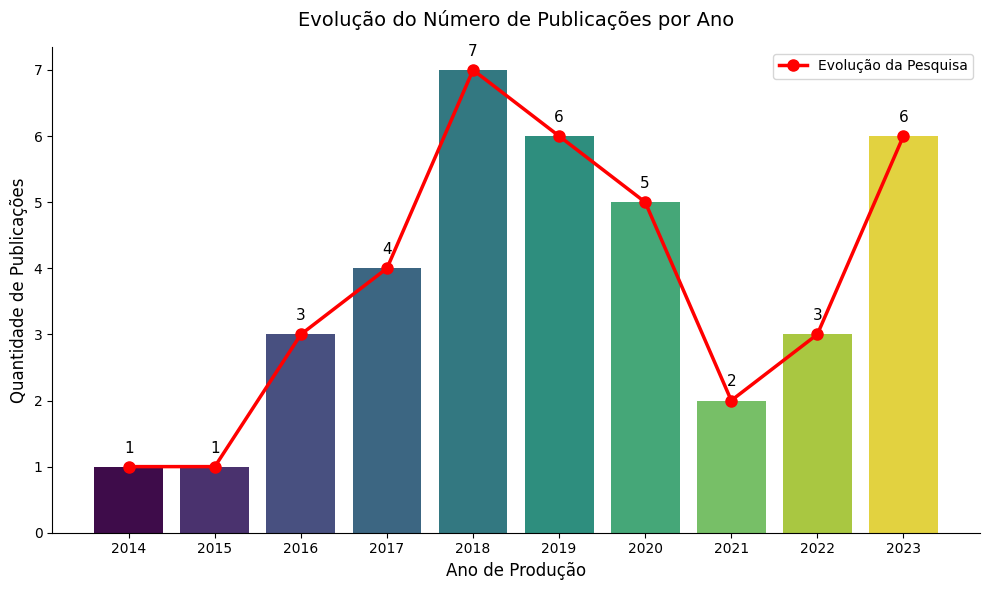

In [30]:
plt.figure(figsize=(10, 6))
ordem_anos = sorted(df['Ano de Produção'].unique()) 


grafico = sns.countplot(
    data=df, 
    x='Ano de Produção', 
    order=ordem_anos,
    hue='Ano de Produção', 
    legend=False,         
    palette='viridis'
)


contagem_por_ano = df['Ano de Produção'].value_counts().reindex(ordem_anos)
posicoes_x = range(len(ordem_anos)) 

plt.plot(posicoes_x, contagem_por_ano.values, color='red', marker='o', 
         linestyle='-', linewidth=2.5, markersize=8, label='Evolução da Pesquisa')


plt.title('Evolução do Número de Publicações por Ano', fontsize=14, pad=15)
plt.xlabel('Ano de Produção', fontsize=12)
plt.ylabel('Quantidade de Publicações', fontsize=12)


for p in grafico.patches:
    altura = p.get_height()
    if altura > 0: 
        grafico.annotate(f'{int(altura)}', 
                         (p.get_x() + p.get_width() / 2., altura), 
                         ha='center', va='bottom', 
                         fontsize=11, color='black', xytext=(0, 8), 
                         textcoords='offset points')

plt.legend()
sns.despine() 
plt.tight_layout()
plt.show()


### 💡 Análise e Insights

O gráfico revela que não houve um crescimento linear na produção científica sobre o tema durante o período analisado. O ano de 2018 destaca-se pelo pico de publicações, seguido por uma diminuição notável entre 2020 e 2022. 

Este declínio coincide perfeitamente com a pandemia de COVID-19, sugerindo um impacto direto nas atividades de pesquisa (visto que pesquisas sobre robótica educacional geralmente dependem fortemente de aplicações práticas e contato direto com os alunos em ambientes escolares que estavam fechados).


### Q1: Quais as regiões do Brasil com maior produção científica?

Abaixo, analisamos a distribuição das publicações para entender se o ensino de robótica está concentrado em alguma região específica do país.

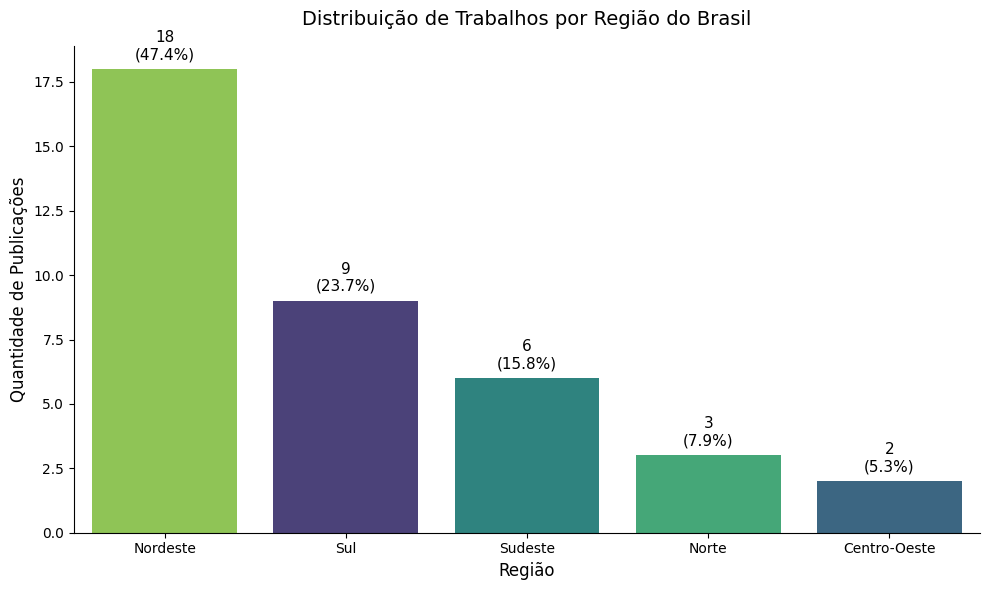

In [31]:
plt.figure(figsize=(10, 6))
total_publicacoes = len(df) 

grafico = sns.countplot(
    data=df, 
    x='Região', 
    order=df['Região'].value_counts().index,
    hue='Região',   
    legend=False,   
    palette='viridis' 
)

plt.title('Distribuição de Trabalhos por Região do Brasil', fontsize=14, pad=15)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Quantidade de Publicações', fontsize=12)


for p in grafico.patches:
    altura = p.get_height()
    if altura > 0:

        porcentagem = (altura / total_publicacoes) * 100
        texto_anotacao = f'{int(altura)}\n({porcentagem:.1f}%)'
        
        grafico.annotate(texto_anotacao, 
                         (p.get_x() + p.get_width() / 2., altura), 
                         ha='center', va='bottom', 
                         fontsize=11, color='black', xytext=(0, 5), 
                         textcoords='offset points')

sns.despine() 
plt.tight_layout()
plt.show()


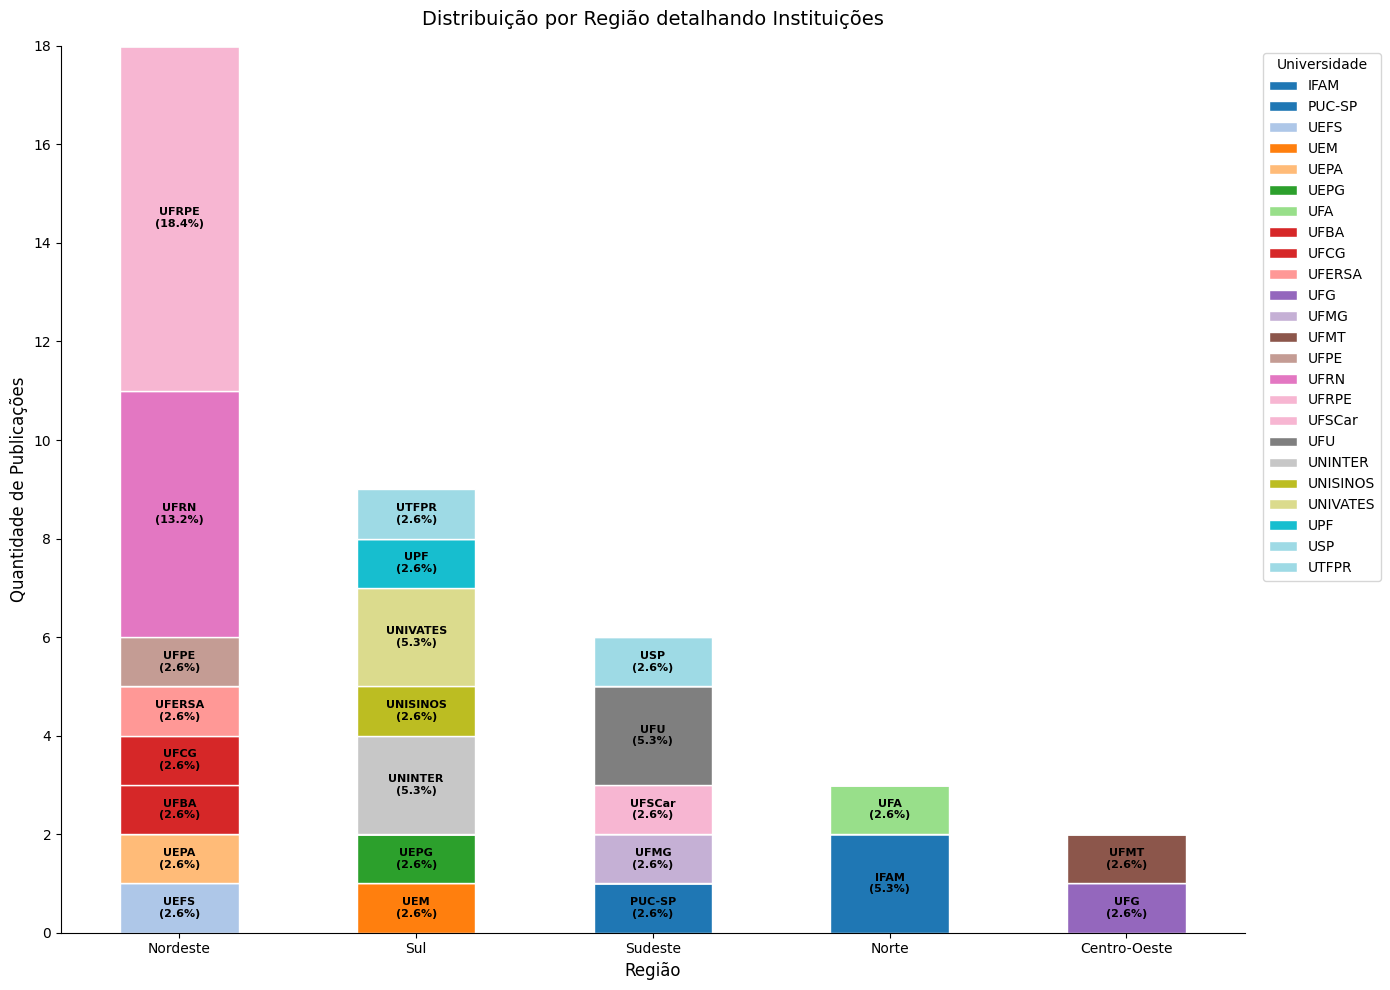

In [32]:
tabela_cruzada = pd.crosstab(df['Região'], df['Abreviação Do Nome da Universidade'])
ordem_regioes = df['Região'].value_counts().index
tabela_cruzada = tabela_cruzada.loc[ordem_regioes]

total_publicacoes = len(df) 

ax = tabela_cruzada.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 10), 
    colormap='tab20',
    edgecolor='white' 
)

plt.title('Distribuição por Região detalhando Instituições', fontsize=14, pad=15)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Quantidade de Publicações', fontsize=12)
plt.xticks(rotation=0)


for c, universidade in enumerate(tabela_cruzada.columns):
    for bloco in ax.containers[c]:
        altura = bloco.get_height()
        
        if altura > 0:

            porcentagem = (altura / total_publicacoes) * 100
            texto = f"{universidade}\n({porcentagem:.1f}%)"
            
            x = bloco.get_x() + bloco.get_width() / 2
            y = bloco.get_y() + altura / 2
            
            ax.annotate(texto, 
                        (x, y), 
                        ha='center', va='center', 
                        fontsize=8, color='black', 
                        fontweight='bold')


plt.legend(title='Universidade', bbox_to_anchor=(1.01, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()


### 💡 Análise e Insights

A concentração de quase 50% das publicações na região Nordeste — com maior destaque para a UFRPE e a UFRN — pode estar fortemente associada ao histórico de incentivo estatal e municipal à robótica educacional na região. 

O programa **"Robótica na Escola"**, promovido pela Prefeitura do Recife, atraiu para a cidade a primeira Célula de Desenvolvimento da LEGO Education (Zoom) fora de sua sede em São Paulo (RECIFE, 2014). 

Além disso, Pernambuco consolidou-se como um estado pioneiro na implementação da robótica educacional em larga escala no Ensino Médio. Em 2012, o Governo do Estado firmou uma grande parceria para a aquisição de 3.200 kits de robótica, atendendo aproximadamente 320 mil alunos (SILVA, 2018). Esse massivo investimento público inicial ajuda a explicar o elevado número de teses e dissertações geradas por pesquisadores dessas universidades locais investigando os impactos da ação.


### Q2: Quais áreas do conhecimento foram exploradas pela robótica e qual o nível de escolaridade foi aplicado?

A seguir, analisamos em quais disciplinas o ensino de robótica tem sido mais utilizado como ferramenta de apoio (como Física, Matemática, Interdisciplinar, etc.) e em quais etapas da educação básica (Ensino Fundamental, Médio ou Técnico) esses projetos costumam ser aplicados na prática.


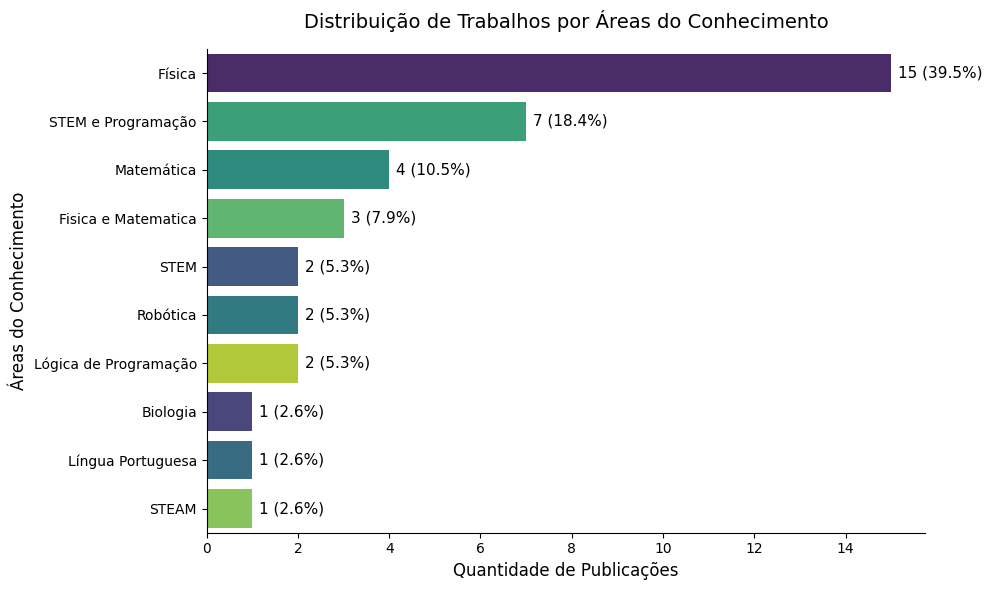

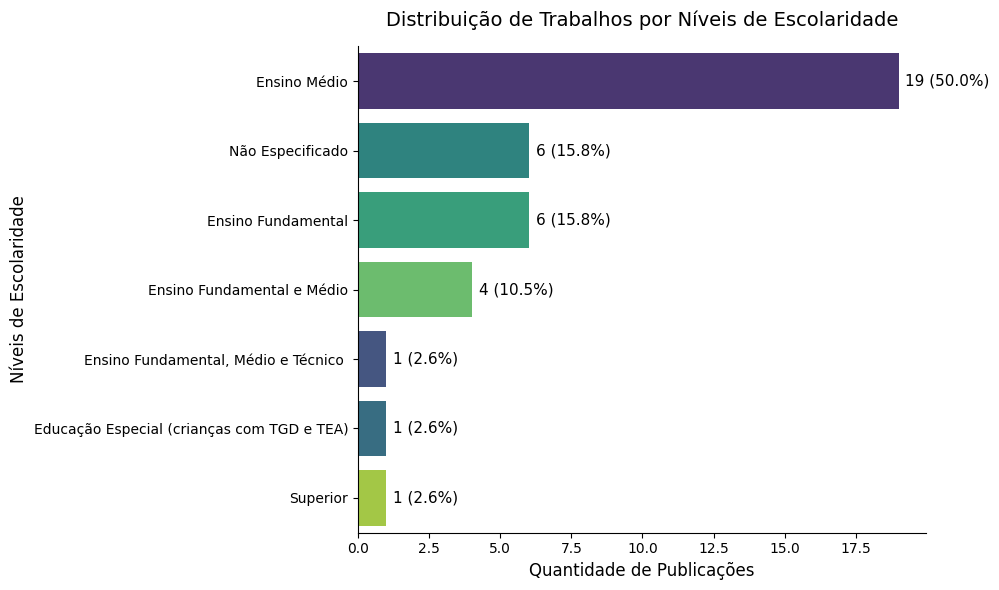

In [33]:
plt.figure(figsize=(10, 6))
total_publicacoes = len(df) 

grafico = sns.countplot(
    data=df, 
    y='Áreas do conhecimento', 
    order=df['Áreas do conhecimento'].value_counts().index,
    hue='Áreas do conhecimento',   
    legend=False,   
    palette='viridis' 
)

plt.title('Distribuição de Trabalhos por Áreas do Conhecimento', fontsize=14, pad=15)
plt.xlabel('Quantidade de Publicações', fontsize=12)
plt.ylabel('Áreas do Conhecimento', fontsize=12)

for p in grafico.patches:
    largura = p.get_width()
    if largura > 0:
        porcentagem = (largura / total_publicacoes) * 100
        texto_anotacao = f'{int(largura)} ({porcentagem:.1f}%)'
        
        grafico.annotate(texto_anotacao, 
                         (largura, p.get_y() + p.get_height() / 2.), 
                         ha='left', va='center', 
                         fontsize=11, color='black', xytext=(5, 0), 
                         textcoords='offset points')

sns.despine() 
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
total_publicacoes = len(df) 

grafico = sns.countplot(
    data=df, 
    y='Níveis de escolaridade', 
    order=df['Níveis de escolaridade'].value_counts().index,
    hue='Níveis de escolaridade',   
    legend=False,   
    palette='viridis' 
)

plt.title('Distribuição de Trabalhos por Níveis de Escolaridade', fontsize=14, pad=15)
plt.xlabel('Quantidade de Publicações', fontsize=12)
plt.ylabel('Níveis de Escolaridade', fontsize=12)

for p in grafico.patches:
    largura = p.get_width()
    if largura > 0:
        porcentagem = (largura / total_publicacoes) * 100
        texto_anotacao = f'{int(largura)} ({porcentagem:.1f}%)'
        
        grafico.annotate(texto_anotacao, 
                         (largura, p.get_y() + p.get_height() / 2.), 
                         ha='left', va='center', 
                         fontsize=11, color='black', xytext=(5, 0), 
                         textcoords='offset points')

sns.despine() 
plt.tight_layout()
plt.show()


### 💡 Análise e Insights

A predominância dessas áreas pode ser justificada pelo fato de que a robótica, enquanto ferramenta educacional, possibilita a concretização de conceitos que são muito abstratos nessas disciplinas (tornando o aprendizado mais prático e visual). 

Em relação ao nível de ensino, como demonstrado no gráfico, a aplicação da robótica educacional concentrou-se fortemente no Ensino Médio. Essa distribuição pode ser explicada pelo fato de que esta etapa escolar exige o desenvolvimento de competências mais complexas, estando diretamente alinhada à preparação do aluno para o mercado de trabalho e para os desafios tecnológicos da sociedade contemporânea.


### Q3: Quais kits de robótica foram utilizados?

Nesta etapa, investigamos quais foram os recursos físicos (kits, plataformas ou peças) mais adotados nas aplicações práticas das pesquisas. Compreender qual kit predomina nos ajuda a analisar se as instituições estão optando por soluções de montagem de baixo custo e código aberto (Open Source) ou por tecnologias proprietárias e comerciais estruturadas.


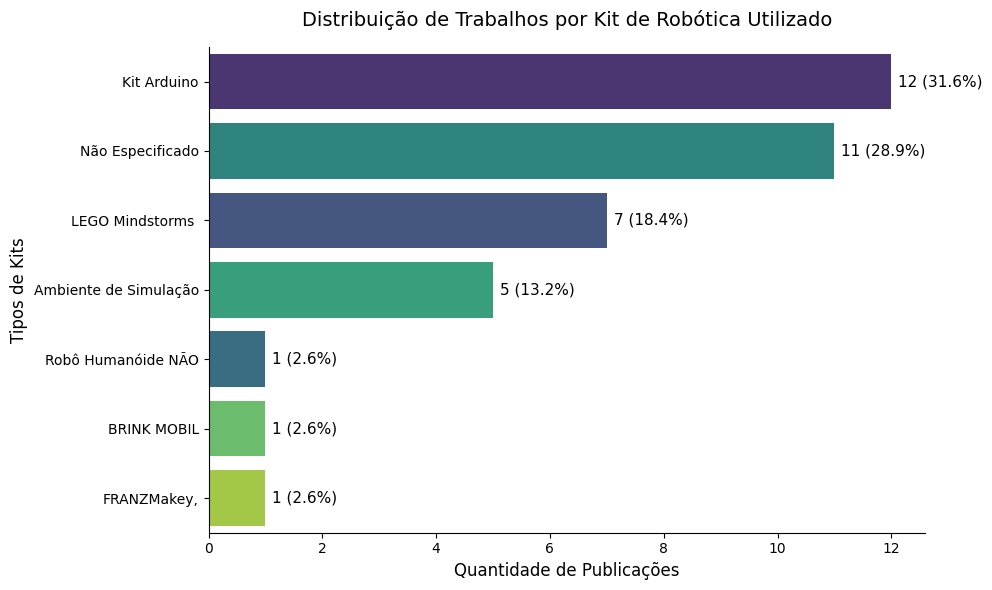

In [34]:
plt.figure(figsize=(10, 6))
total_publicacoes = len(df) 

grafico = sns.countplot(
    data=df, 
    y='Qual Kit usou', 
    order=df['Qual Kit usou'].value_counts().index,
    hue='Qual Kit usou',   
    legend=False,   
    palette='viridis' 
)

plt.title('Distribuição de Trabalhos por Kit de Robótica Utilizado', fontsize=14, pad=15)
plt.xlabel('Quantidade de Publicações', fontsize=12)
plt.ylabel('Tipos de Kits', fontsize=12)

for p in grafico.patches:
    largura = p.get_width()
    if largura > 0:
        porcentagem = (largura / total_publicacoes) * 100
        texto_anotacao = f'{int(largura)} ({porcentagem:.1f}%)'
        
        grafico.annotate(texto_anotacao, 
                         (largura, p.get_y() + p.get_height() / 2.), 
                         ha='left', va='center', 
                         fontsize=11, color='black', xytext=(5, 0), 
                         textcoords='offset points')

sns.despine() 
plt.tight_layout()
plt.show()


### 💡 Análise e Insights

A predominância desses dois kits nas pesquisas pode ser explicada pela diferença de acessibilidade e foco pedagógico de cada um:

* **LEGO Mindstorms:** Embora tenha um custo elevado (o que limita sua adoção em escolas públicas), possui enorme adesão por oferecer montagem simples, programação visual em blocos para iniciantes e um forte suporte pedagógico com tutoriais da própria empresa.
* **Kit Arduino:** Caracteriza-se pelo baixo custo e uso de *hardware/software livre* (Open Source). Ele estimula a personalização avançada e permite a integração com materiais alternativos (como recicláveis), promovendo abordagens criativas, sustentáveis e economicamente viáveis.

Em resumo, a escolha do kit dita o tipo de competência técnica e cognitiva desenvolvida: o LEGO atende à construção estruturada com suporte intuitivo, enquanto o Arduino abre portas para o desenvolvimento eletrônico flexível e acessível.


---
# 🎯 Conclusão Geral e Considerações Finais

A partir desta Análise Exploratória sobre as teses e dissertações envolvendo a robótica educacional na educação básica brasileira, foi possível extrair aprendizados importantes e identificar os principais desafios do cenário nacional:

* **Limitação e Qualidade dos Dados:** Um dos obstáculos da pesquisa foi a amostragem reduzida de trabalhos que efetivamente continham estudos de caso aplicados na prática escolar. Somado a isso, notou-se a falta de detalhamento metodológico por parte de alguns autores, especialmente na falta de identificação exata de quais kits de robótica foram utilizados nas aulas.
* **O Peso do Incentivo Governamental:** Os dados comprovaram que o incentivo do Estado é o motor principal para alavancar a produção científica. O pico de publicações concentrado em Pernambuco (Nordeste) é o maior reflexo de que políticas públicas focadas em inserir tecnologia nas escolas geram resultados acadêmicos e práticos imediatos.
* **A Barreira Estrutural vs. Acessibilidade:** Mesmo com a extrema facilidade e intuição oferecidas pelas plataformas da *LEGO*, a falta de infraestrutura financeira das escolas brasileiras impõe uma barreira gigante. É nesse cenário de dificuldade que o *Arduino* ganha força: por mais que não seja tão intuitivo ou pronto quanto o LEGO, o seu baixo custo permite democratizar a robótica e dar a ela um alcance territorial muito maior.
* **O Impacto da Pandemia de COVID-19:** A análise temporal deixou evidente a queda nas pesquisas práticas. Como a robótica exige contato presencial, infraestrutura física e manuseio de peças, o fechamento das escolas inviabilizou a continuidade de grande parte dos estudos de caso com alunos durante a pandemia.


## 📚 Referências Bibliográficas

* PREFEITURA DO RECIFE. Programa de robótica da Prefeitura atrai investimento da LEGO Zoom para o Recife. 14 mar. 2014. Disponível em: https://www2.recife.pe.gov.br/noticias/14/03/2014/programa-de-robotica-da-prefeitura-atrai -investimento-da-lego-zoom-para-o-recife. Acesso em: 1 ago. 2025.
* SILVA, Heitor Felipe da. Robótica educacional como recurso pedagógico fomentador do letramento científico de alunos da rede pública de ensino na cidade do Recife. 2018. Trabalho acadêmico – Universidade Federal de Pernambuco, Recife, 2018.
